# Sleep-Stage Classification — Decision Tree

A **single decision tree**, tuned as high as it will honestly go.

A decision tree is the most *interpretable* model — you can read the rules and see which features
drive each split — but it is also **weak on this data**: it draws axis-aligned, piecewise-constant
boundaries, while the classes overlap smoothly (see the LDA plot in the SVM notebook). So expect
~**0.68 macro-F1**, well below the RBF-SVM (~0.83). The value here is *understanding*, not the top score.

**What we do:** light EDA → show the depth/overfitting trade-off → tune the tree properly →
read its feature importances and visualize it → submit. Trees need **no scaling**, which keeps it simple.

## 0. Setup & load data

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

target   = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]
y  = train[target].values
classes = sorted(np.unique(y))
print("train:", train.shape, "| test:", test.shape, "| features:", len(features), "| classes:", classes)
train[features].head()

train: (9000, 23) | test: (5000, 22) | features: 21 | classes: [0, 1, 2, 3]


,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,eeg_kcomplex_rate,...,emg_tone_variance,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index
0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,-1.66370,...,-1.76807,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230
1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,-0.03516,...,-0.35469,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271
2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,-0.53028,...,1.49050,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN
3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,-0.65535,...,1.12176,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040
4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,-1.04615,...,-0.31044,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947


# Quick EDA (decision-driving only)

## 1. Target balance

   count   pct
0   2001  22.2
1   2442  27.1
2   2237  24.9
3   2320  25.8
Majority-class baseline macro-F1 ≈ 0.271


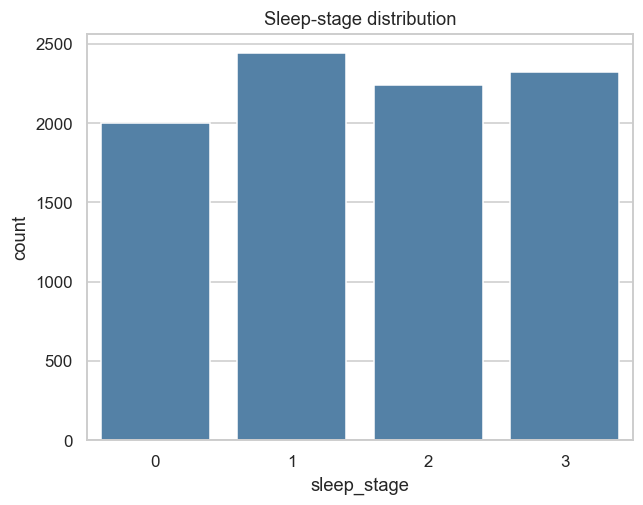

In [2]:
counts = pd.Series(y).value_counts().sort_index()
print(pd.DataFrame({"count": counts, "pct": (counts/len(y)*100).round(1)}))
print(f"Majority-class baseline macro-F1 ≈ {counts.max()/len(y):.3f}")
sns.barplot(x=counts.index, y=counts.values, color="steelblue")
plt.title("Sleep-stage distribution"); plt.xlabel("sleep_stage"); plt.ylabel("count"); plt.show()
# 4 balanced classes -> StratifiedKFold + macro-F1.

## 2. Missing values

In [3]:
miss = pd.DataFrame({"train_%": (train[features].isna().mean()*100).round(1),
                     "test_%":  (test[features].isna().mean()*100).round(1)})
print(miss[miss.sum(axis=1) > 0])
# Only `eog_burst_index` (~50%). We median-impute inside the pipeline (trees need a complete matrix here).

                 train_%  test_%
eog_burst_index     50.0    49.5


## 3. Feature signal — mutual information

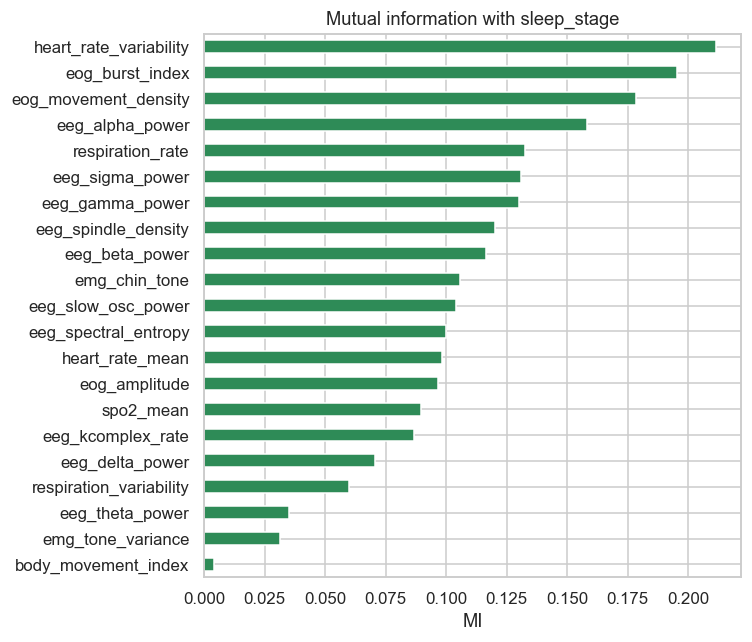

In [4]:
from sklearn.feature_selection import mutual_info_classif
X_mi = train[features].fillna(train[features].median())
mi = pd.Series(mutual_info_classif(X_mi, y, random_state=RANDOM_STATE), index=features).sort_values()
mi.plot.barh(figsize=(7, 6), color="seagreen"); plt.title("Mutual information with sleep_stage")
plt.xlabel("MI"); plt.tight_layout(); plt.show()
# A few EEG / heart / EOG features carry most signal; `body_movement_index` ≈ 0 (noise).

# Modeling — Decision Tree

Trees are **scale-invariant**, so no `StandardScaler`. We only median-impute the one missing column.
All scoring is **out-of-fold** on a shared `StratifiedKFold(5)` (no leakage).

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay

X  = train[features]
Xt = test[features]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tree_pipe(**kw):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("dt",  DecisionTreeClassifier(random_state=RANDOM_STATE, **kw))])

def oof_f1(model):
    pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    return f1_score(y, pred, average="macro")

## 4. Baseline — a default (unpruned) tree

In [6]:
print(f"default DecisionTree OOF macro-F1 = {oof_f1(tree_pipe()):.4f}")
# A fully-grown tree overfits (memorizes train) -> mediocre OOF. Pruning/regularizing helps.

default DecisionTree OOF macro-F1 = 0.6740


## 5. The core trade-off — tree depth
A tree's single most important knob is **depth**. Too shallow → underfits; too deep → overfits.
We plot OOF macro-F1 vs `max_depth` to find the sweet spot — the classic bias/variance curve.

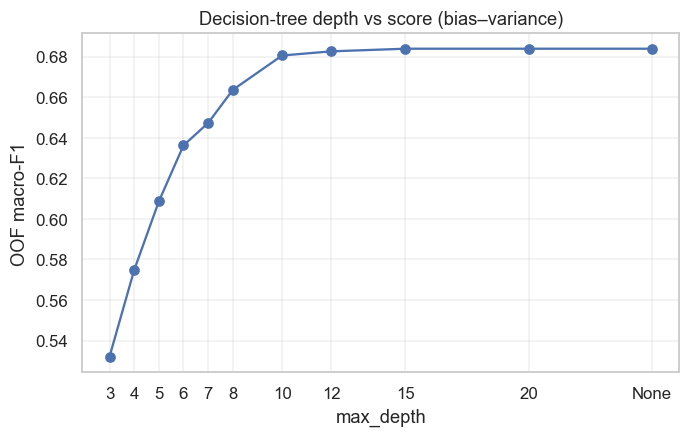

best depth here: 15 -> 0.6839


In [7]:
depths = [3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
curve = []
for d in depths:
    curve.append(oof_f1(tree_pipe(max_depth=d, criterion="entropy", min_samples_leaf=20)))
xs = [d if d is not None else 25 for d in depths]
plt.figure(figsize=(7, 4))
plt.plot(xs, curve, marker="o")
plt.xticks(xs, [str(d) for d in depths]); plt.xlabel("max_depth"); plt.ylabel("OOF macro-F1")
plt.title("Decision-tree depth vs score (bias–variance)"); plt.grid(True, alpha=.3); plt.show()
print("best depth here:", depths[int(np.argmax(curve))], "->", round(max(curve), 4))
# Score climbs then plateaus ~0.68 -> a single tree simply can't separate the overlapping classes.

## 6. Tune the tree properly
`RandomizedSearchCV` over the regularization knobs that control a tree: split criterion, depth,
leaf/split sizes, `max_features`, `class_weight`, and **cost-complexity pruning** (`ccp_alpha`).

In [8]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    "dt__criterion":         ["gini", "entropy"],
    "dt__max_depth":         [6, 8, 10, 12, 15, None],
    "dt__min_samples_leaf":  [5, 10, 20, 30, 50, 75, 100],
    "dt__min_samples_split": [2, 10, 20, 50],
    "dt__max_features":      [None, "sqrt", 0.5, 0.7],
    "dt__class_weight":      [None, "balanced"],
    "dt__ccp_alpha":         [0.0, 1e-4, 5e-4, 1e-3],
}
search = RandomizedSearchCV(tree_pipe(), param_dist, n_iter=150, scoring="f1_macro",
                            cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X, y)
best_tree = search.best_estimator_
print(f"best CV macro-F1 = {search.best_score_:.4f}")
print("best params:", {k.split('__')[1]: v for k, v in search.best_params_.items()})

best CV macro-F1 = 0.6826
best params: {'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': None, 'max_depth': 12, 'criterion': 'entropy', 'class_weight': None, 'ccp_alpha': 0.001}


## 7. Is the tuned score stable? (multi-seed)

In [9]:
ms = []
for s in [42, 1, 2, 7, 123]:
    cvs = StratifiedKFold(5, shuffle=True, random_state=s)
    ms.append(f1_score(y, cross_val_predict(best_tree, X, y, cv=cvs, n_jobs=-1), average="macro"))
ms = np.array(ms)
print(f"multi-seed OOF macro-F1: mean={ms.mean():.4f}  std={ms.std():.4f}")

multi-seed OOF macro-F1: mean=0.6746  std=0.0060


## 8. What the tree learned — importances & error pattern

              precision    recall  f1-score   support

           0      0.720     0.729     0.725      2001
           1      0.718     0.737     0.727      2442
           2      0.599     0.594     0.596      2237
           3      0.694     0.672     0.683      2320

    accuracy                          0.683      9000
   macro avg      0.683     0.683     0.683      9000
weighted avg      0.683     0.683     0.683      9000



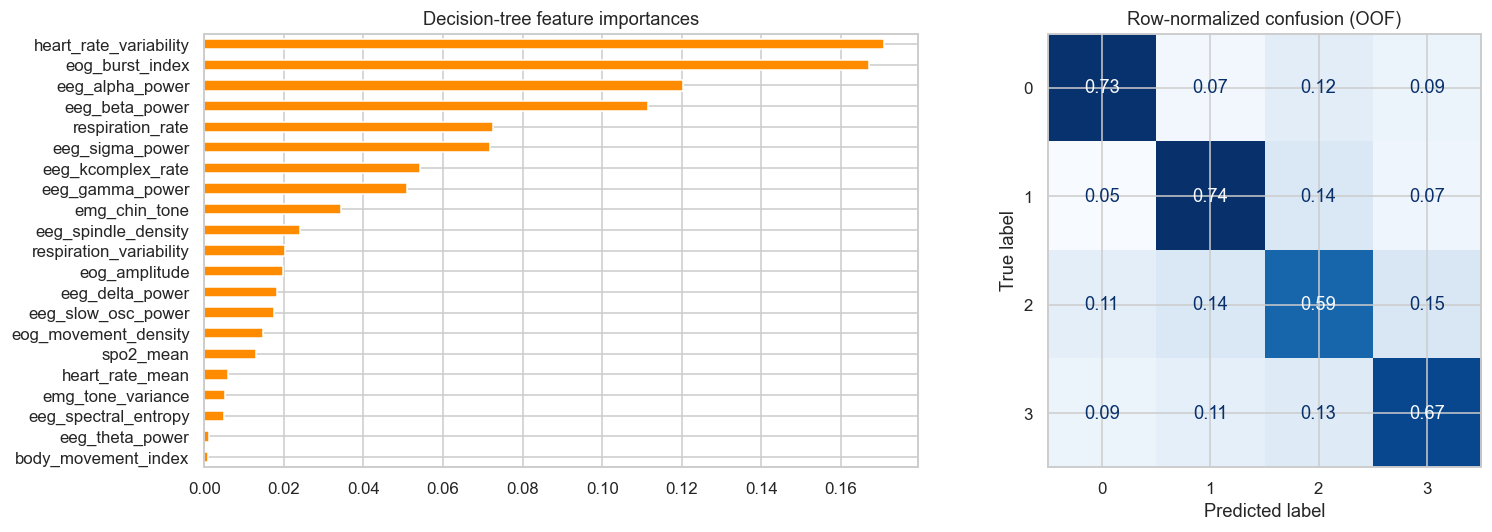

In [10]:
oof_pred = cross_val_predict(best_tree, X, y, cv=cv, n_jobs=-1)
print(classification_report(y, oof_pred, digits=3))

# Feature importances (a tree gives these for free)
best_tree.fit(X, y)
imp = pd.Series(best_tree.named_steps["dt"].feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
imp.plot.barh(ax=ax[0], color="darkorange"); ax[0].set_title("Decision-tree feature importances")
ConfusionMatrixDisplay.from_predictions(y, oof_pred, normalize="true", display_labels=classes,
                                        cmap="Blues", values_format=".2f", ax=ax[1], colorbar=False)
ax[1].set_title("Row-normalized confusion (OOF)")
plt.tight_layout(); plt.show()
# class 2 is hardest and leaks into neighbours -> the same overlap the SVM hit, but worse here.

## 9. Read the top of the tree
The big selling point of a decision tree: you can literally read its rules. We draw the **top 3 levels**
(the full tree is far too large to show). Each node lists the split rule and the class it leans toward.

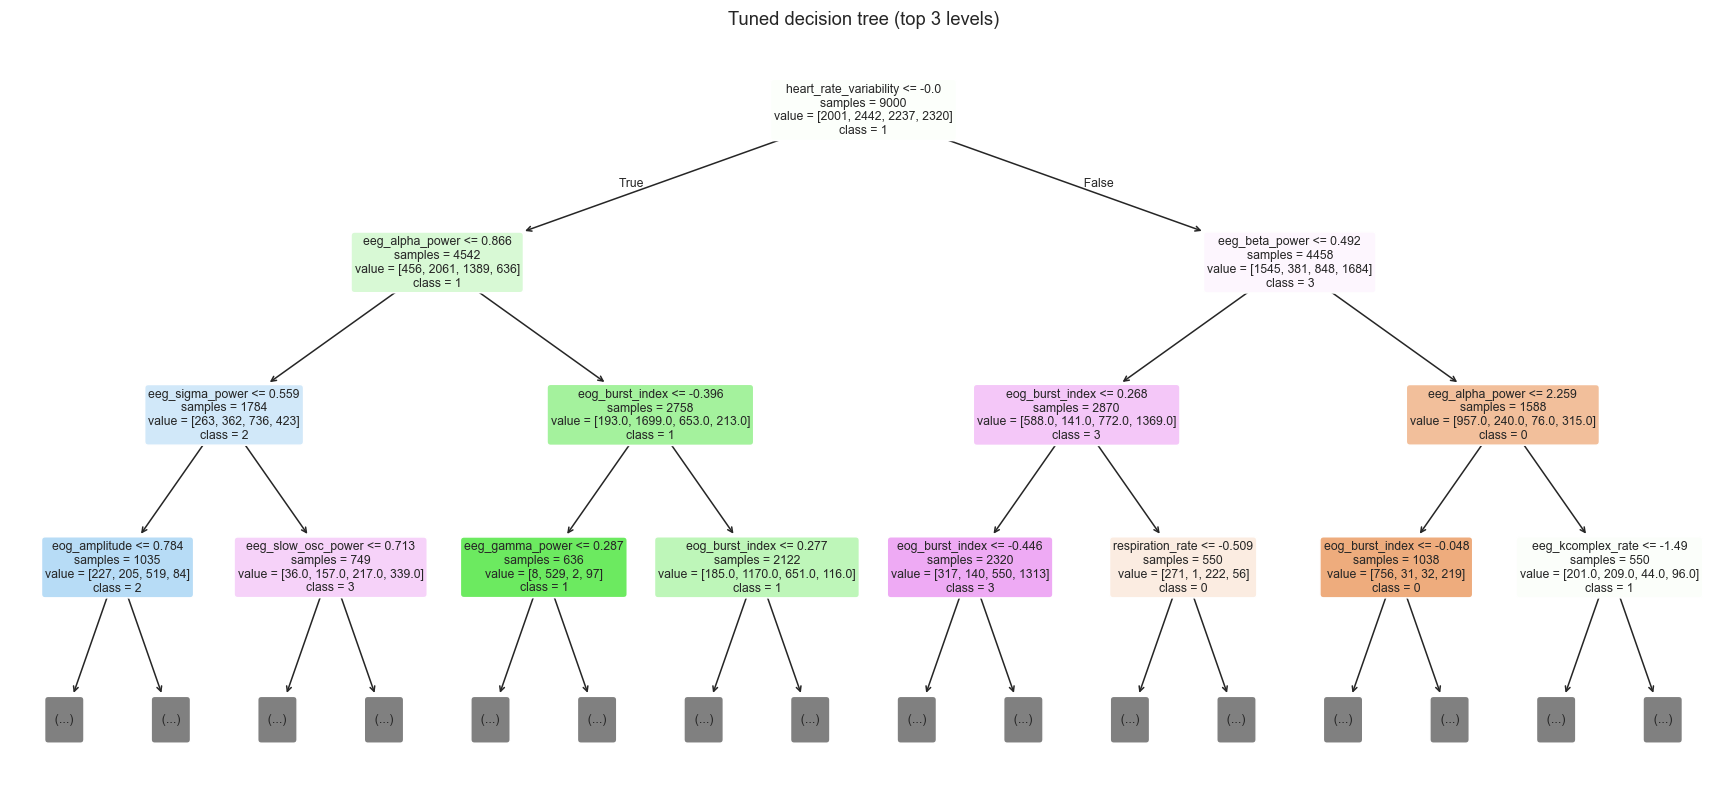

In [11]:
plt.figure(figsize=(20, 9))
plot_tree(best_tree.named_steps["dt"], max_depth=3, feature_names=features,
          class_names=[str(c) for c in classes], filled=True, rounded=True, fontsize=8, impurity=False)
plt.title("Tuned decision tree (top 3 levels)"); plt.show()

## 10. Final model & submission
Refit the tuned tree on all training data and predict the test set.

In [12]:
final_tree = best_tree.fit(X, y)
test_pred = final_tree.predict(Xt)
submission = pd.DataFrame({"id": test["id"], target: test_pred})[sample_submission.columns]
submission.to_csv("destree.csv", index=False)
print(f"Tuned tree OOF macro-F1 = {f1_score(y, oof_pred, average='macro'):.4f}")
print("Saved submission.csv:", submission.shape)
print("\nClass distribution (train vs predicted test):")
print(pd.DataFrame({"train": pd.Series(y).value_counts(normalize=True).sort_index(),
                    "test_pred": pd.Series(test_pred).value_counts(normalize=True).sort_index()}).round(3))
submission.head()

Tuned tree OOF macro-F1 = 0.6828
Saved submission.csv: (5000, 2)

Class distribution (train vs predicted test):
   train  test_pred
0  0.222      0.206
1  0.271      0.273
2  0.249      0.256
3  0.258      0.264


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,2
3,9003,3
4,9004,1


### Takeaway
A fully tuned single decision tree reaches only ~**0.68 macro-F1** — far below the RBF-SVM's ~0.83.
The reason is structural: the classes overlap smoothly, and a tree can only cut axis-aligned boxes.
Its real strengths are **interpretability** (readable rules, free feature importances) and **zero scaling**.
To beat ~0.68 you must move to models that average many trees (RandomForest, gradient boosting) or
draw smooth boundaries (SVM) — which is exactly why those win on this dataset.